## Computer Vision

Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and $k$NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

2026-02-27 21:54:24.163739: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 21:54:24.163995: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 21:54:24.205493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 21:54:25.456971: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

---------------- Part 1 ---------------

7 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0 

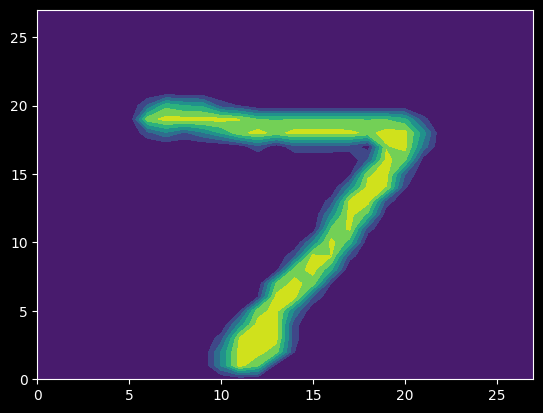

2 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 116 125 171 255 255 150  93   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 169 253 253 253 253 253 253 218  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 253 253 253 213 142 176 253 253 122   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  52 250 253 210  32  12   0   6 206 253 140   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  31  18   0   0   0   0 209 253 253  65   

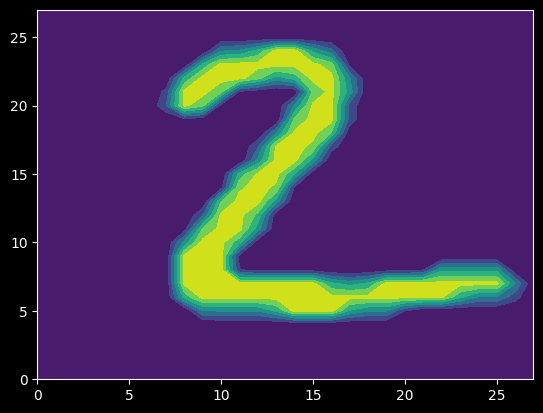

1 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38 254 109   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  87 252  82   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 135 241   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  45 244 150   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  84 254  63   

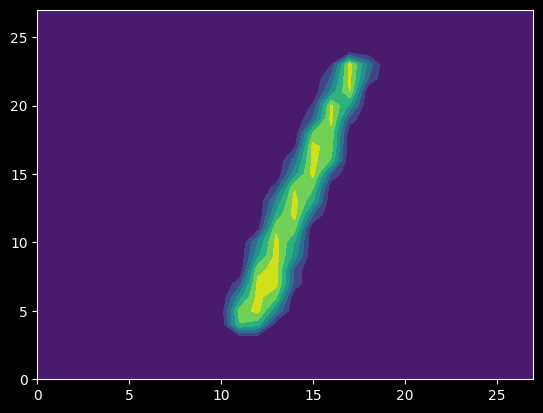

0 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  11 150 253 202  31   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  37 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  21 197 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 110 190 251 251 251 253 169 109  62   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 253 251 251 251 251 253 251 251 22

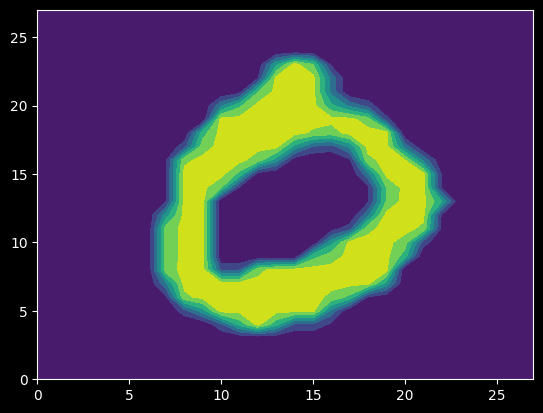

4 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  50 224   0   0   0   0   0   0   0  70  29   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 121 231   0   0   0   0   0   0   0 148 168   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   4 195 231   0   0   0   0   0   0   0  96 210  11   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  69 252 134   0   0   0   0   0   0   

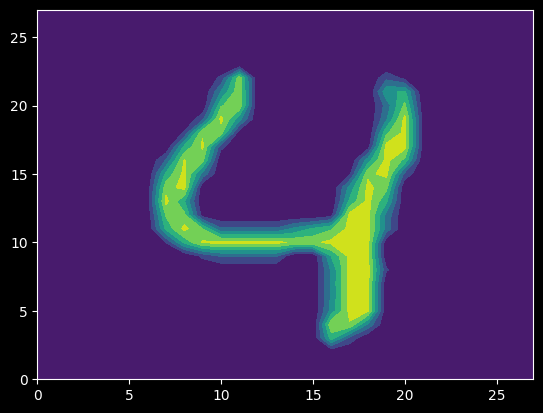


---------------- Part 2 ---------------

(60000, 28, 28) 

(10000, 28, 28) 

(60000,) 

(10000,) 

(28, 28) 

(28, 28) 

(28, 28) 

(28, 28) 

(28, 28) 

(28, 28) 

(28, 28) 

(28, 28) 

(28, 28) 

(28, 28) 

It seems that the shape of both X and Y is 60k, therefore making a cube type shape. Each sub I is a 28x28 area. The test shape, on the other hand, is a 10k area.

---------------- Part 3 ---------------

(60000, 784) 

(10000, 784) 


---------------- Part 4+5 ---------------

The accuracy is: 0.9665666666666667 

The most optimal number of neighbors is: [1]


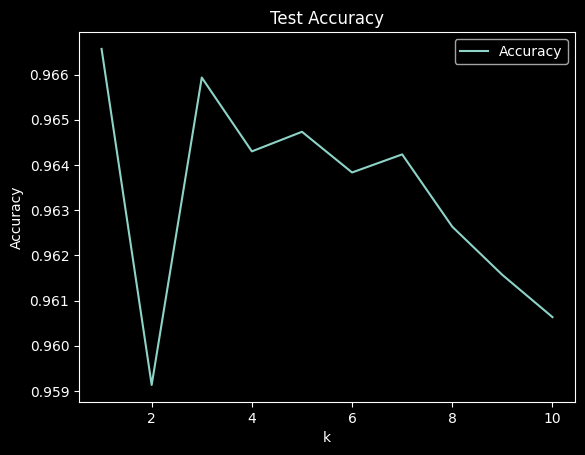

col_0     0     1     2     3     4     5     6     7     8     9
row_0                                                            
0      2975     5     5     0     0     6    11     2     1     1
1         1  3358     9     0     6     1     2    10     1     2
2        25    49  2841    11     2     1     6    43     7     6
3         4     9    14  2907     2    40     4    29    18    15
4         2    30     0     1  2779     0    12     3     1    90
5         6     6     2    25     7  2547    35     1     8    15
6        15     9     1     0     2    16  2938     0     1     0
7         1    43     8     1    12     1     0  3012     0    32
8         9    55    10    63    12    62    15    11  2684    46
9         7    11     2    27    33     8     1    40     7  2806
It seems very accurate for the most part, it had an accuracy of around 0.97, or 97%, and the confusion matrix shows that the majority of the numbers are in that diagonal path, showing an accuracy to predicted

In [1]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
df = mnist.load_data('minst.db')

print("\n" + "---------------- Part 1 ---------------" + "\n")
train,test = df
X_train, y_train = train
X_test, y_test = test
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()

print("\n" + "---------------- Part 2 ---------------" + "\n")
print(X_train.shape,'\n')
print(X_test.shape,'\n')
print(y_train.shape,'\n')
print(y_test.shape,'\n')
for i in range (5):
    print(X_train[i].shape,'\n')
    print(X_test[i].shape,'\n')
print("It seems that the shape of both X and Y is 60k, therefore making a cube type shape. Each sub I is a 28x28 area. The test shape, on the other hand, is a 10k area.")

print("\n" + "---------------- Part 3 ---------------" + "\n")
X_train_reshape = X_train.reshape(60000, 784)
X_test_reshape = X_test.reshape(10000, 784)
def maxmin(z):
    z = (z - z.min()) / (z.max() - z.min())
    return(z)
X_train_reshape = maxmin(X_train_reshape)
X_test_reshape = maxmin(X_test_reshape)
print(X_train_reshape.shape,'\n')
print(X_test_reshape.shape,'\n')

print("\n" + "---------------- Part 4+5 ---------------" + "\n")
X_train, X_test, y_train, y_test = train_test_split(X_train_reshape,y_train,test_size=.5, random_state=13)
#k_bar = 40; Lowered due to long times, tested originally with this and it gave 1.
k_bar = 10
Acc = []
N_train = len(y_train)
N_test = len(y_test)

for k in range(k_bar):
    model = KNeighborsClassifier(n_neighbors=k+1)
    fitted_model = model.fit(X_train,y_train)
    y_hat = fitted_model.predict(X_test)
    Acc.append( np.sum( y_hat == y_test )/N_test )

Acc_max = np.max(Acc)
print("The accuracy is: " + str(Acc_max) ,'\n')
max_index = np.where(Acc==Acc_max)
k_star = max_index[0]+1
print("The most optimal number of neighbors is: " + str(k_star))

model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
fitted_model = model.fit(X_train,y_train)
y_hat = fitted_model.predict(X_test)
plt.plot(np.arange(1,k_bar+1),Acc,label='Accuracy')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend(loc='upper right')
plt.title('Test Accuracy')
plt.show()
print(pd.crosstab(y_test,y_hat))

print("It seems very accurate for the most part, it had an accuracy of around 0.97, or 97%, and the confusion matrix shows that the majority of the numbers are in that diagonal path, showing an accuracy to predicted pair. There are some numbers not in this section, but only 3% are wrongfully predicted.")

print("\n" + "---------------- Part 6 ---------------" + "\n")
print("There are some weird patterns in the data, for example: The numbers wrongfully predicted are more towards the lower ends of the matrix (when the real diagonal is on the upper ends) and towards the middle of the matrix (when the real diagonal is on the lower ends). This is a real trend, showing not much data was wrongfully predicted to be in upper columns. Row 3 and 9 seemed to have the most errors, being around the middle and lower ends. ")

print("\n" + "---------------- Part 7 ---------------" + "\n")
print("Colors have 3 main values, which are red, green, and blue. These values would have to be shown in the array/matrix, meaning that multiple color arrays could possible be stacked on each other, with the visibility or directness of the array depending on the value of the color code, 0-255. For a kNN classifer, this would be very similar to the current process, except you would need 3 times as many vectors values, or l*w*3, to get an accurate recording. ")
